In [1]:
# Welcome to your new notebook
# Type here in the cell editor to add code!
# se importan las librerías

#import tensorflow as tf
#from tensorflow import keras
#from keras.models import Sequential
#from keras import Input
#from keras.layers import Dense, SimpleRNN
import warnings
import optuna
import xgboost
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import TimeSeriesSplit
import pandas as pd
import numpy as np
import math
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from prophet import Prophet


import optuna
import numpy as np
import optuna.visualization as vis
#vis.plot_optimization_history(study)
import matplotlib.dates as mdates

# visualización
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("viridis")
import plotly.graph_objects as go
import prophet
#tf.random.set_seed(42)
np.random.seed(42)

c:\Users\JUAN DAVID\Desktop\maestria docs\codigo python\venv_tesis\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Dataframe

tickers = ["NVDA", 
           "^SPX"
           #"^NDX"
           ]

# Leer fechas base desde el archivo principal
dates = pd.read_csv("../data/csv/NVDA_data.csv")
date_close = pd.DataFrame({"Date": pd.to_datetime(dates["Date"])})

# Unir los archivos de cada ticker
for ticker in tickers:
    file_name = ticker.replace("^", "")
    data_ticket = pd.read_csv(f"../data/csv/{file_name}_data.csv")
    data_ticket["Date"] = pd.to_datetime(data_ticket["Date"])
    close_col = f"{file_name}_Close" if f"{file_name}_Close" in data_ticket.columns else "Close"

    date_close = pd.merge(
        date_close,
        data_ticket[["Date", close_col]].rename(columns={close_col: file_name}),
        on="Date",
        how="left"
    )

# Ordenar por fecha
df_data_close_or = date_close.sort_values(by="Date", ascending=True)

# 🔸 Rellenar fechas faltantes (Prophet requiere serie continua)
# Paso 1: establecer índice y frecuencia diaria
df_data_close_or = df_data_close_or.set_index("Date").asfreq("B")

# Paso 2: interpolar valores de SPX y NVDA en días sin datos
#df_data_close["NVDA"] = df_data_close["NVDA"].interpolate(method="linear")
#df_data_close["SPX"] = df_data_close["SPX"].interpolate(method="linear")

# Paso 3: eliminar posibles NaN iniciales (si faltan al principio)
df_data_close_or = df_data_close_or.dropna(subset=["NVDA", "SPX"])

# Paso 4: limitar el rango (si es necesario)
#df_data_close = df_data_close[df_data_close.index <= "2025-01-01"]

# Reiniciar índice
df_data_close_or = df_data_close_or.reset_index()

df_data_close_or


,Date,NVDA,SPX
0,2021-01-04,13.077453,3700.649902
1,2021-01-05,13.367903,3726.860107
2,2021-01-06,12.579823,3748.139893
3,2021-01-07,13.307318,3803.790039
4,2021-01-08,13.240255,3824.679932
...,...,...,...
1101,2025-05-22,132.813293,5842.009766
1102,2025-05-23,131.273483,5802.819824
1103,2025-05-27,135.482941,5921.540039
1104,2025-05-28,134.793045,5888.549805


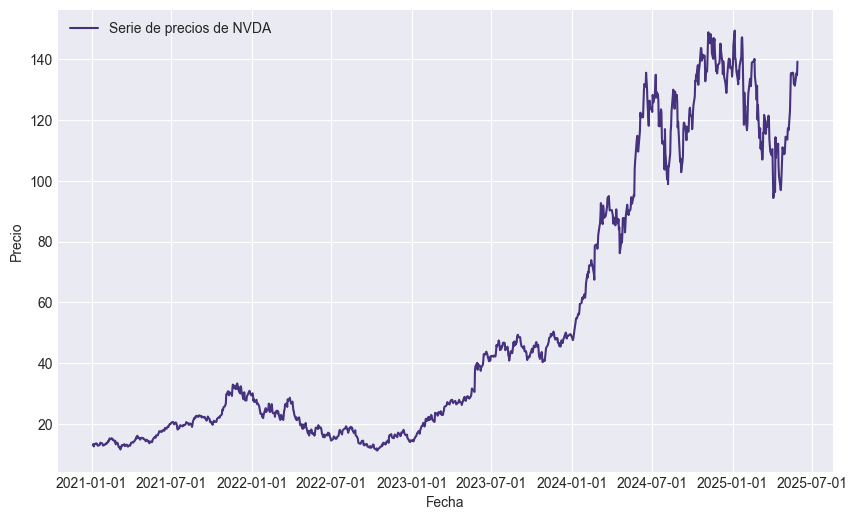

In [3]:
# se grafican los datos - serie original
plt.figure(figsize=(10,6))
plt.plot(df_data_close_or["Date"], df_data_close_or["NVDA"], label="Serie de precios de NVDA")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend()
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator())  # Espacia automáticamente las fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))  # Formato legible
plt.grid(True)
plt.show()

Se transforma y diferencia la serie

In [4]:
df_data_close = df_data_close_or.copy()
#df_data_close["NVDA_log"] = np.log(df_data_close_or["NVDA"])
#df_data_close["NVDA_diff"] = np.log(df_data_close["NVDA"]).diff()
#df_data_close["SPX_diff"] = np.log(df_data_close["SPX"]).diff()
df_data_close = df_data_close.dropna()
#df_data_close = df_data_close[["Date", "NVDA_diff", "SPX_diff"]]
df_data_close = df_data_close[["Date", "NVDA", "SPX"]]
df_data_close


,Date,NVDA,SPX
0,2021-01-04,13.077453,3700.649902
1,2021-01-05,13.367903,3726.860107
2,2021-01-06,12.579823,3748.139893
3,2021-01-07,13.307318,3803.790039
4,2021-01-08,13.240255,3824.679932
...,...,...,...
1101,2025-05-22,132.813293,5842.009766
1102,2025-05-23,131.273483,5802.819824
1103,2025-05-27,135.482941,5921.540039
1104,2025-05-28,134.793045,5888.549805


In [5]:
# entrenamiento y prueba
# se deja un porcentaje para ver la extrapolación del modelo 
percentage = 0.9
folds_size = int(len(df_data_close) * percentage )
folds_data = df_data_close.loc[df_data_close.index <= folds_size] 
val_data = df_data_close.loc[df_data_close.index > folds_size] 
fecha_corte = folds_data["Date"][-1:].values[0]
fecha_corte


np.datetime64('2024-12-17T00:00:00.000000000')

In [6]:
# se renombran las columnas par el uso de la librería
#folds_data = folds_data.rename(columns={"NVDA_diff": "y", "Date": "ds"})
folds_data = folds_data.rename(columns={"NVDA": "y", "Date": "ds"})
folds_data


,ds,y,SPX
0,2021-01-04,13.077453,3700.649902
1,2021-01-05,13.367903,3726.860107
2,2021-01-06,12.579823,3748.139893
3,2021-01-07,13.307318,3803.790039
4,2021-01-08,13.240255,3824.679932
...,...,...,...
991,2024-12-11,139.279648,6084.189941
992,2024-12-12,137.310089,6051.250000
993,2024-12-13,134.220764,6051.089844
994,2024-12-16,131.971237,6074.080078


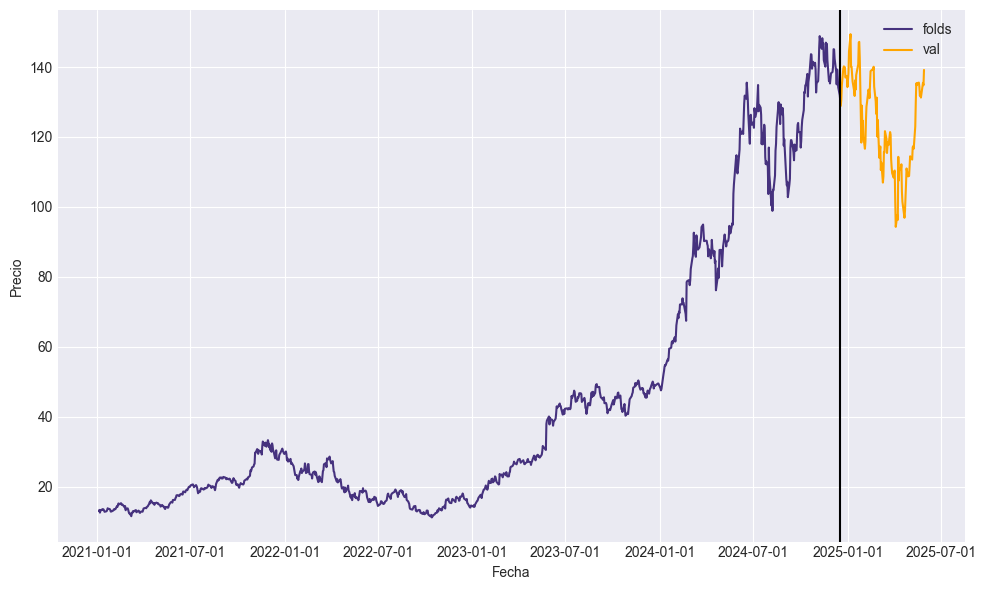

In [7]:
# se grafican los datos
plt.figure(figsize=(10,6))
plt.plot(folds_data["ds"], folds_data["y"], label="folds")
#plt.plot(val_data["Date"], val_data["NVDA_diff"], label="val", color="orange")
plt.plot(val_data["Date"], val_data["NVDA"], label="val", color="orange")
plt.axvline(fecha_corte, color="black", linestyle="-")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend()
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator())  # Espacia automáticamente las fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))  # Formato legible
plt.tight_layout()
plt.grid(True)
plt.show()

In [1]:
# visualizacion de los folds 
# se muestra de forma visual como funcionan los folds
# si no se define el tamaño de test, en la primera iteracion se toma igual cantidad de datos para train que para test
# por eso se toman los folds de prueba como de la longitud de datos de validación
#size_test = int(len(val_data) * 0.4)
size_test = int(len(folds_data) * 0.05)

gap = 0 # distancia (cantidad de observaciones) que se deja entre train y test
#tscv = TimeSeriesSplit(n_splits=6, test_size=size_test, gap=gap)
tscv = TimeSeriesSplit(
    n_splits=8,
    test_size=size_test,
    gap=0
)

folds, indexes, types = [], [], []

for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(folds_data)):
    folds.extend([fold_idx] * len(train_idx)) 
    indexes.extend(train_idx)
    types.extend(['Train'] * len(train_idx))

    folds.extend([fold_idx] * len(test_idx))
    indexes.extend(test_idx)
    types.extend(['Test'] * len(test_idx))

# figura con plotly
fig = go.Figure()

# data train
fig.add_trace(go.Scatter(
    x=indexes, y=folds,
    mode='markers',
    marker=dict(color=['blue' if t == 'Train' else 'orange' for t in types], size=6),
    text=types,
    hovertemplate='Index: %{x}<br> Fold: %{y}<br> Tipo: %{text}<extra></extra>'
))

fig.update_layout(
    title='Folds',
    xaxis_title='Indices serie',
    yaxis_title='Fold',
    yaxis=dict(autorange='reversed'),
    legend_title='Tipo de conjunto',
    template='plotly_white',
    height=400
)
fig.show()

NameError: name 'folds_data' is not defined

definir función de optimización con optuna viendo los parámetros (temporalidades y demás), de acuerdo con una métrica de error

In [9]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
import numpy as np
import pandas as pd

def objective(trial):
    """
    Función objetivo para optimizar Prophet con Optuna sin regresores adicionales.
    Entrena sobre el logaritmo del precio (no sobre retornos), lo que estabiliza la varianza
    y evita la acumulación exponencial de error en la reconstrucción fuera de muestra.
    Penaliza además la varianza entre folds para priorizar configuraciones estables.
    """

    # ================================================================
    # Hiperparámetros a optimizar
    # ================================================================
    params = {
        "changepoint_prior_scale": trial.suggest_float("changepoint_prior_scale", 0.01, 10.0, log=True),
        "growth": trial.suggest_categorical("growth", ["linear", "flat"]),
        "seasonality_prior_scale": trial.suggest_float("seasonality_prior_scale", 1.0, 20.0, log=True),
        "holidays_prior_scale": trial.suggest_float("holidays_prior_scale", 0.01, 10.0, log=True),
        "seasonality_mode": trial.suggest_categorical("seasonality_mode", ["additive", "multiplicative"]),
        "changepoint_range": trial.suggest_float("changepoint_range", 0.8, 0.95),
        "fourier_order_monthly": trial.suggest_int("fourier_order_monthly", 3, 10),
        "period": trial.suggest_float("period", 1, 60)
    }

    # ================================================================
    # Transformación del target a log(precio)
    # ================================================================
    df = folds_data.copy()
    df["y_level"] = df["y"]  # precios originales
    df["y"] = np.log(df["y_level"])  # trabajamos en log-precios
    df = df.dropna().reset_index(drop=True)

    # ================================================================
    # Inicialización de métricas
    # ================================================================
    mapes, maes, rmses = [], [], []

    # ================================================================
    # Validación cruzada temporal
    # ================================================================
    for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(df)):
        train = df.iloc[train_idx].copy()
        test = df.iloc[test_idx].copy()

        # ------------------------------------------------------------
        # Definición y entrenamiento del modelo Prophet
        # ------------------------------------------------------------
        model = Prophet(
            changepoint_prior_scale=params["changepoint_prior_scale"],
            seasonality_prior_scale=params["seasonality_prior_scale"],
            holidays_prior_scale=params["holidays_prior_scale"],
            seasonality_mode=params["seasonality_mode"],
            changepoint_range=params["changepoint_range"],
            weekly_seasonality=True,
            yearly_seasonality=True,
            daily_seasonality=False
        )
        model.add_seasonality(name="monthly", period=params["period"], fourier_order=params["fourier_order_monthly"])

        model.fit(train[["ds", "y"]])

        # ------------------------------------------------------------
        # Predicción sobre el conjunto de prueba
        # ------------------------------------------------------------
        future = test[["ds"]].copy()
        forecast = model.predict(future)

        # Reconstrucción de precios reales
        test["y_level_pred"] = np.exp(forecast["yhat"].values)  # revertir log

        # ------------------------------------------------------------
        # Métricas de error sobre precios reales
        # ------------------------------------------------------------
        y_true = test["y_level"].values
        y_pred = test["y_level_pred"].values

        mae = mean_absolute_error(y_true, y_pred)
        mape = mean_absolute_percentage_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))

        mapes.append(mape)
        maes.append(mae)
        rmses.append(rmse)

        # Guardar resultados del fold
        trial.set_user_attr(f"fold_{fold_idx + 1}", {"mae": mae, "mape": mape, "rmse": rmse})
        trial.report(np.mean(mapes), step=fold_idx)

    # ================================================================
    # Penalización por varianza entre folds
    # ================================================================
    mean_mape = np.mean(mapes)
    std_mape = np.std(mapes)
    penalized_mape = float(mean_mape + 0.5 * std_mape)

    # ================================================================
    # Registro final y retorno
    # ================================================================
    trial.set_user_attr("mean_mape", mean_mape)
    trial.set_user_attr("std_mape", std_mape)
    trial.set_user_attr("penalized_mape", penalized_mape)

    return penalized_mape


In [10]:



print("Optimización con Optuna")
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

best_params = study.best_params
print("Mejores parámetros encontrados:\n", best_params)


[I 2025-11-11 23:43:46,332] A new study created in memory with name: no-name-8b37640c-8b43-4be2-abac-ed91353636a2


Optimización con Optuna


23:43:47 - cmdstanpy - INFO - Chain [1] start processing
23:43:51 - cmdstanpy - INFO - Chain [1] done processing
23:43:52 - cmdstanpy - INFO - Chain [1] start processing
23:43:54 - cmdstanpy - INFO - Chain [1] done processing
23:43:55 - cmdstanpy - INFO - Chain [1] start processing
23:43:58 - cmdstanpy - INFO - Chain [1] done processing
23:43:58 - cmdstanpy - INFO - Chain [1] start processing
23:44:01 - cmdstanpy - INFO - Chain [1] done processing
23:44:01 - cmdstanpy - INFO - Chain [1] start processing
23:44:05 - cmdstanpy - INFO - Chain [1] done processing
23:44:06 - cmdstanpy - INFO - Chain [1] start processing
23:44:11 - cmdstanpy - INFO - Chain [1] done processing
23:44:11 - cmdstanpy - INFO - Chain [1] start processing
23:44:14 - cmdstanpy - INFO - Chain [1] done processing
23:44:14 - cmdstanpy - INFO - Chain [1] start processing
23:44:18 - cmdstanpy - INFO - Chain [1] done processing
23:44:19 - cmdstanpy - INFO - Chain [1] start processing
23:44:22 - cmdstanpy - INFO - Chain [1]

Mejores parámetros encontrados:
 {'changepoint_prior_scale': 4.313426057889937, 'growth': 'flat', 'seasonality_prior_scale': 3.9457767688190577, 'holidays_prior_scale': 5.418429262129704, 'seasonality_mode': 'additive', 'changepoint_range': 0.8377566467748359, 'fourier_order_monthly': 6, 'period': 56.2762555667977}


In [11]:
best_params

{'changepoint_prior_scale': 4.313426057889937,
 'growth': 'flat',
 'seasonality_prior_scale': 3.9457767688190577,
 'holidays_prior_scale': 5.418429262129704,
 'seasonality_mode': 'additive',
 'changepoint_range': 0.8377566467748359,
 'fourier_order_monthly': 6,
 'period': 56.2762555667977}

In [12]:
# Extraer resultados del mejor trial
best_trial = study.best_trial
print("Mejor trial:", best_trial.number)
print("MAPE promedio:", best_trial.value)
print("Atributos guardados:")
print(best_trial.user_attrs)


Mejor trial: 35
MAPE promedio: 0.07915052219159957
Atributos guardados:
{'fold_1': {'mae': 14.21192853591142, 'mape': 0.10549435345554425, 'rmse': np.float64(14.249849751100628)}, 'fold_2': {'mae': 8.509390300487624, 'mape': 0.0616829518707467, 'rmse': np.float64(8.74875015840568)}, 'fold_3': {'mae': 3.7060110689194743, 'mape': 0.026152536347613248, 'rmse': np.float64(4.25425498013257)}, 'fold_4': {'mae': 6.766850892540856, 'mape': 0.05006296512199428, 'rmse': np.float64(8.06076323839922)}, 'fold_5': {'mae': 8.914991111634759, 'mape': 0.06157642724794676, 'rmse': np.float64(9.578494141738673)}, 'fold_6': {'mae': 17.823467026086206, 'mape': 0.12389683985966457, 'rmse': np.float64(18.31328890591732)}, 'fold_7': {'mae': 5.867927417144694, 'mape': 0.04154641161599053, 'rmse': np.float64(6.574484791671169)}, 'fold_8': {'mae': 13.40316177889631, 'mape': 0.09743131448335815, 'rmse': np.float64(13.568126671993076)}, 'fold_9': {'mae': 2.913763791509183, 'mape': 0.021226884952913295, 'rmse': np.

In [13]:
# info de los trials 
# se extraen los trials
trials = study.get_trials()
for trial in trials:
    trial_number = trial.number # número de trial: trial 1, 2,...
    attrs = trial.user_attrs
    #print(attrs)

In [14]:
# creación del df a nivel de registro
# el esquema del df se infiere a partir de las claves almacenadas 
# en cada registro (las claves no varían)
rows = [] # se usará para guardar la info a nivel de registro
for trial in trials:
    trial_number = trial.number # número de trial: trial 1, 2,...
    attrs = trial.user_attrs # los valores de las métricas se definen en la función como 
    # un atributo de usuario, definido como un diccionario
    # se recorren ahora las claves y los valores de cada diccionario
    for key, value in attrs.items():
        if key.startswith("fold_") and isinstance(value, dict): 
            # se examina si cada clave del diccionario empieza con fold_. Recordar que en la función
            # se guardó un diccionario con el nombre fold_i_metrics, que guarda la info de cada fold y cada trial.
            # Se mira entonces si la clave es de esa forma y si el valor de esa clave es un diccionario
            rows.append({
                "trial": trial_number,
                "fold": value.get("fold"),
                "mape": value.get("mape"),
                "mae": value.get("mae"),
                "rmse": value.get("rmse"),
            }) 
df_metrics = pd.DataFrame(rows)
df_metrics.head()

,trial,fold,mape,mae,rmse
0,0,None,0.110325,14.892449,15.255419
1,0,None,0.112438,15.481376,15.704708
2,0,None,0.069456,9.817219,10.034788
3,0,None,0.145826,19.854486,20.531615
4,0,None,0.261740,38.019400,38.069760


In [15]:
# descripción general del df de métricas
df_stats = df_metrics.describe()
df_stats[["mape", "mae", "rmse"]]

,mape,mae,rmse
count,500.000000,500.000000,500.000000
mean,0.151943,21.259349,21.784282
std,0.110472,15.788674,15.746841
min,0.006282,0.846214,0.984244
25%,0.070101,9.767418,10.761597
50%,0.133783,18.588614,19.119869
75%,0.196469,27.187119,27.401620
max,0.727911,105.873947,106.913966


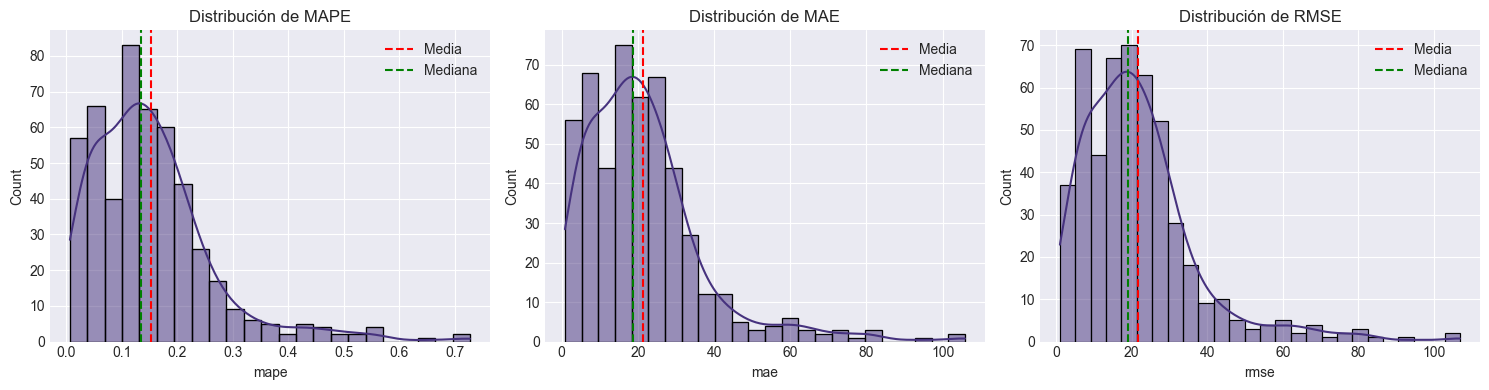

In [16]:
# histogramas de los errores por trial y por fold
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric in zip(axes, ["mape", "mae", "rmse"]):
    sns.histplot(df_metrics[metric], kde=True, ax=ax)
    ax.set_title(f"Distribución de {metric.upper()}")
    ax.axvline(df_metrics[metric].mean(), color='red', linestyle='--', label='Media')
    ax.axvline(df_metrics[metric].median(), color='green', linestyle='--', label='Mediana')
    """ if metric == 'mape':
        medians_df['mape'] = df_metrics[metric].median() """
    ax.legend()

plt.tight_layout()
plt.show()


In [17]:
model = prophet.Prophet(
    changepoint_prior_scale=best_params['changepoint_prior_scale'],
    seasonality_prior_scale=best_params["seasonality_prior_scale"],
    holidays_prior_scale=best_params["holidays_prior_scale"],
    seasonality_mode=best_params["seasonality_mode"],
    changepoint_range=best_params["changepoint_range"]
)
model.fit(folds_data)


23:57:45 - cmdstanpy - INFO - Chain [1] start processing
23:57:47 - cmdstanpy - INFO - Chain [1] done processing


In [18]:
future = model.make_future_dataframe(periods=len(val_data), freq="B", include_history=False)
forecast = model.predict(future)
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2024-12-18,144.353661,134.078769,141.498545,144.353661,144.353661,-6.541527,-6.541527,-6.541527,2.865634,2.865634,2.865634,-9.407161,-9.407161,-9.407161,0.0,0.0,0.0,137.812134
1,2024-12-19,144.626964,134.329973,141.657284,144.626964,144.626964,-6.754900,-6.754900,-6.754900,3.059226,3.059226,3.059226,-9.814126,-9.814126,-9.814126,0.0,0.0,0.0,137.872064
2,2024-12-20,144.900268,133.583016,141.634544,144.900268,144.900268,-7.295205,-7.295205,-7.295205,2.915539,2.915539,2.915539,-10.210744,-10.210744,-10.210744,0.0,0.0,0.0,137.605063
3,2024-12-23,145.720179,133.456994,141.069062,145.720179,145.720179,-8.509463,-8.509463,-8.509463,2.824113,2.824113,2.824113,-11.333576,-11.333576,-11.333576,0.0,0.0,0.0,137.210716
4,2024-12-24,145.993483,133.235354,140.984524,145.993483,145.993483,-8.792308,-8.792308,-8.792308,2.892031,2.892031,2.892031,-11.684339,-11.684339,-11.684339,0.0,0.0,0.0,137.201175


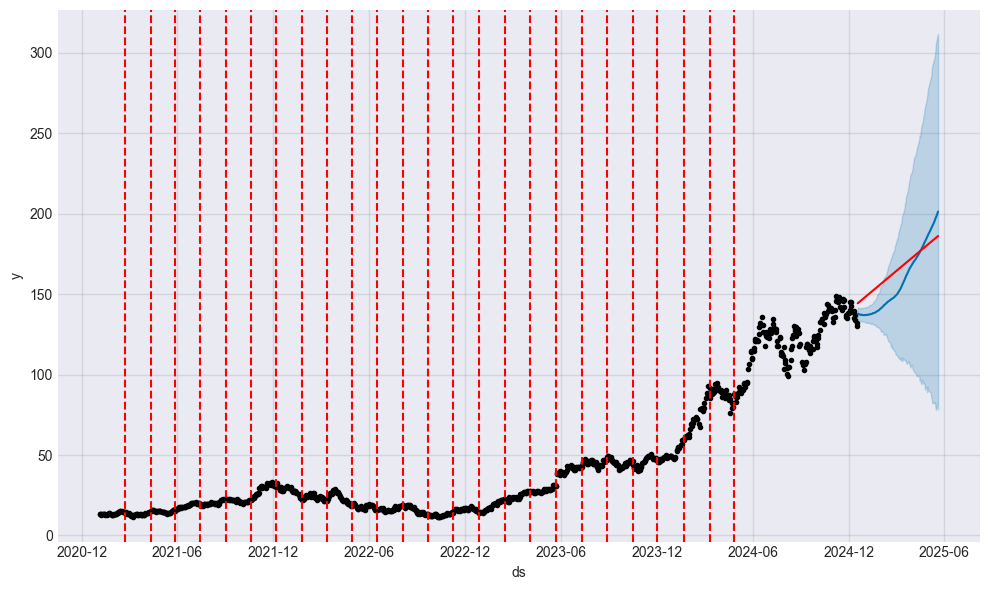

In [19]:
from prophet.plot import add_changepoints_to_plot
fig = model.plot(forecast)
a = add_changepoints_to_plot(fig.gca(),
                             model, forecast)

In [20]:
#plt.figure(figsize=(12,6))
#plt.plot(df_data_close["Date"][:-len(val_data)], df_data_close["NVDA"][:-len(val_data)], label="Precio real NVDA - train", color="gray")
#plt.plot(df_data_close["Date"][-len(val_data):], df_data_close["NVDA_diff"][-len(val_data):], label="Precio real NVDA")
#plt.plot(df_data_close["Date"][-len(val_data):], df_data_close["NVDA_diff"][-len(val_data):], label="Precio real NVDA")
#plt.plot(df_data_close["Date"][-len(val_data):], forecast["yhat"][-len(val_data):], label="Precio pronosticado Prophet", color="orange")
#plt.legend()
#plt.show()

In [21]:
#last_y = folds_data['y'].iloc[-1]
#forecast['yhat_level'] = np.exp(last_y + forecast['yhat'].cumsum())

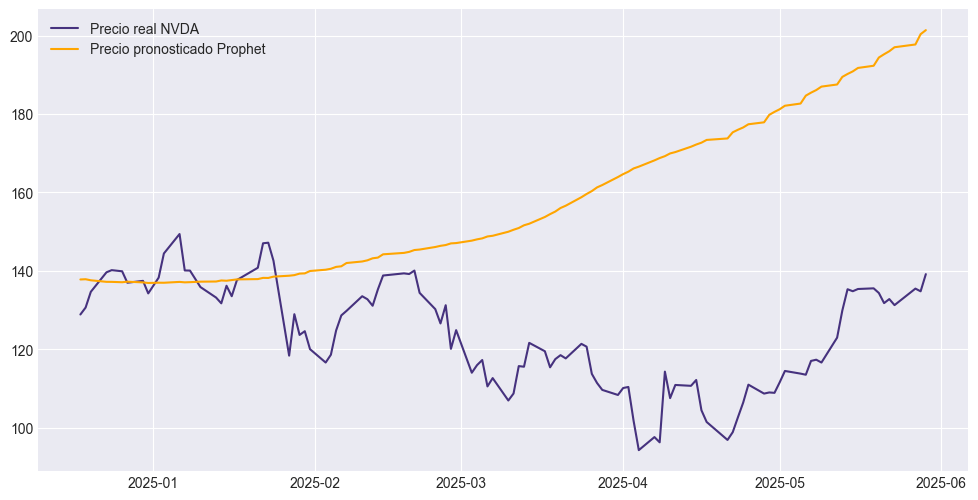

In [22]:
plt.figure(figsize=(12,6))
#plt.plot(df_data_close["Date"][:-len(val_data)], df_data_close["NVDA"][:-len(val_data)], label="Precio real NVDA - train", color="gray")
plt.plot(df_data_close_or["Date"][-len(val_data):], df_data_close_or["NVDA"][-len(val_data):], label="Precio real NVDA")
plt.plot(df_data_close_or["Date"][-len(val_data):], forecast["yhat"][-len(val_data):], label="Precio pronosticado Prophet", color="orange")
plt.legend()
plt.show()